<a href="https://colab.research.google.com/github/AlemayehuDabi/AI-ML/blob/main/intro_ml/magic_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [2]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("/content/magic04.data", names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [3]:
df["class"].unique()

array(['g', 'h'], dtype=object)

In [4]:
df["class"] = (df["class"] == "g").astype(int)

In [5]:
pd.set_option('display.max_rows', None)
df.head(5)

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


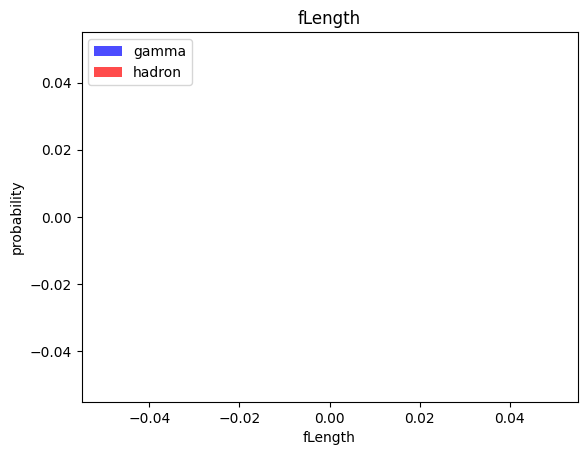

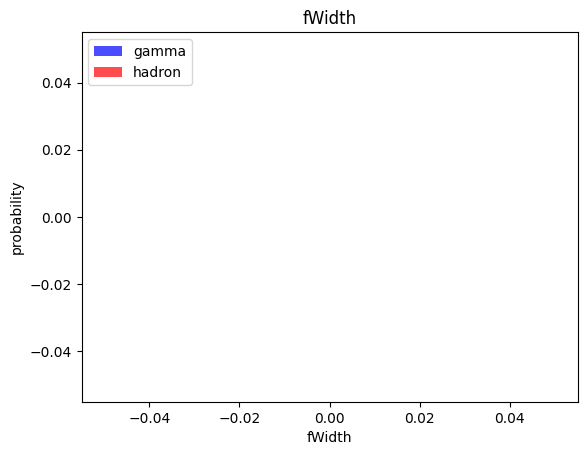

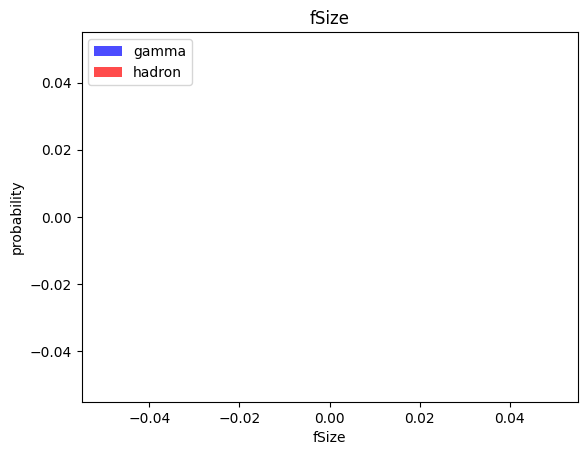

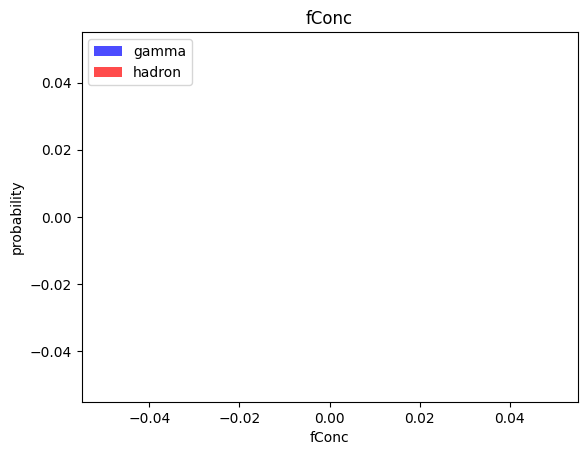

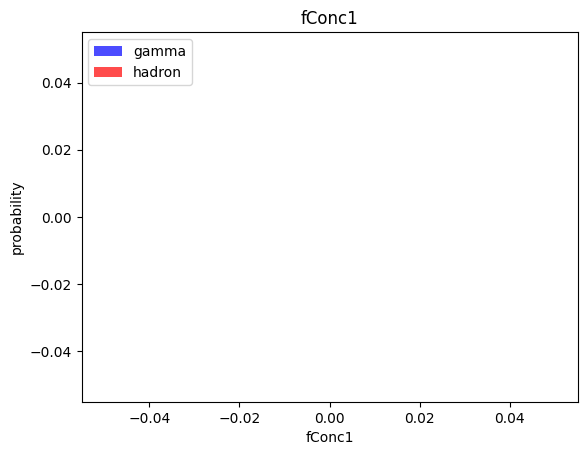

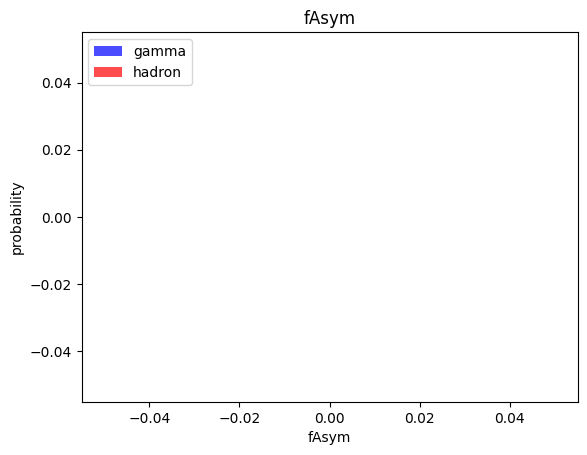

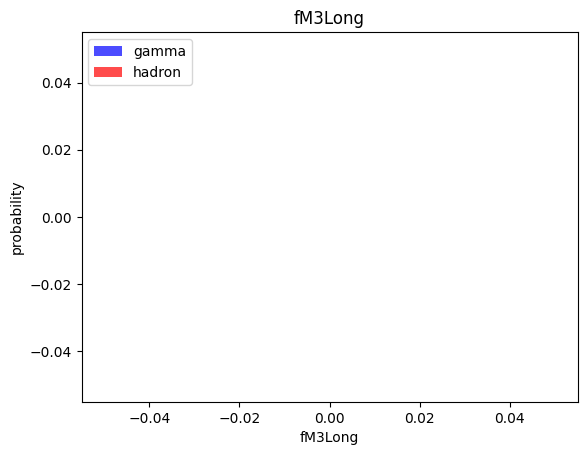

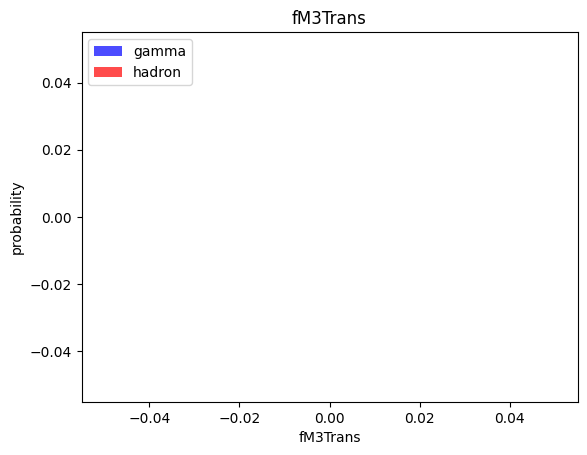

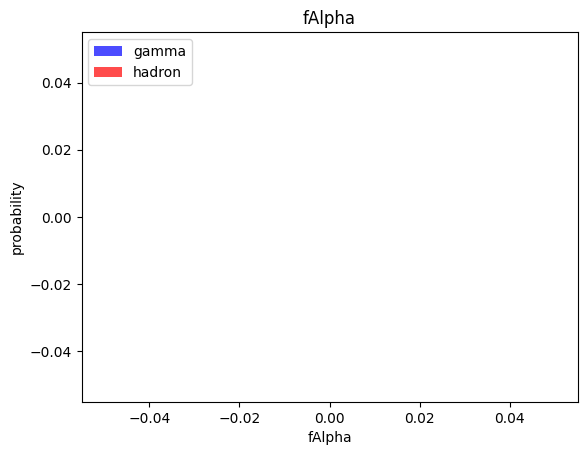

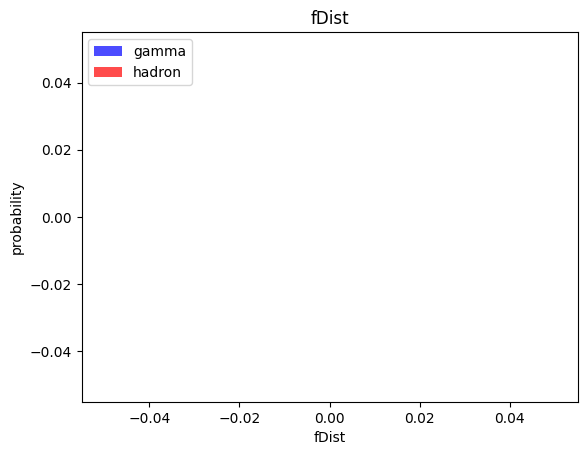

In [ ]:
for label in cols[:-1]:
  plt.hist(df[df["class"]==1][label], color="Blue", label="gamma", alpha=0.7, density=True)
  plt.hist(df[df["class"]==0][label], color="Red", label="hadron", alpha=0.7, density=True)
  plt.title(label)
  plt.xlabel(label)
  plt.ylabel("probability")
  plt.legend()
  plt.show()


Train, validation and testing datasets

In [6]:
train, validation, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [7]:
def scale_dataset(dataframe, over_sampling=False):
  X = df[df.columns[:-1]].values
  Y = df[df.columns[-1]].values

  scaler = StandardScaler()
  X = scaler.fit_transform(X)

  ros = RandomOverSampler()

  X, Y = ros.fit_resample(X,Y)

  data = np.hstack((X,np.reshape(Y, (-1,1))))

  return data, X, Y

In [8]:
train, X_train, Y_train = scale_dataset(train, over_sampling=True)
validation, X_validation, Y_validation = scale_dataset(validation, over_sampling=False)
test, X_test, Y_test = scale_dataset(test, over_sampling=False)

# ***KNN***

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [10]:
knn_model = KNeighborsClassifier(n_neighbors=10)
knn_model.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=10)

In [11]:
Y_predict = knn_model.predict(X_test)

In [12]:
Y_predict

array([1, 0, 0, ..., 0, 1, 0])

In [13]:
Y_test

array([1, 1, 1, ..., 0, 0, 0])

In [14]:
print(classification_report(Y_test, Y_predict))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86     12332
           1       0.84      0.88      0.86     12332

    accuracy                           0.86     24664
   macro avg       0.86      0.86      0.86     24664
weighted avg       0.86      0.86      0.86     24664



# ***NAVIE BAYES***

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_model = GaussianNB()
nb_model =  nb_model.fit(X_train, Y_train)

In [ ]:
Y_predict = nb_model.predict(X_test)

In [ ]:
print(classification_report(Y_test, Y_predict))

              precision    recall  f1-score   support

           g       0.60      0.90      0.72     12332
           h       0.80      0.40      0.53     12332

    accuracy                           0.65     24664
   macro avg       0.70      0.65      0.63     24664
weighted avg       0.70      0.65      0.63     24664



# ***Logistic Regression***

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, Y_train)

In [ ]:
Y_predict = lg_model.predict(X_test)

In [ ]:
print(classification_report(Y_test, Y_predict))

              precision    recall  f1-score   support

           g       0.74      0.82      0.78     12332
           h       0.80      0.72      0.76     12332

    accuracy                           0.77     24664
   macro avg       0.77      0.77      0.77     24664
weighted avg       0.77      0.77      0.77     24664



# ***Support Vector Machine***

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC()


In [ ]:
svm_model = svm_model.fit(X_train, Y_train)

In [ ]:
Y_predict = svm_model.predict(X_test)

In [ ]:
print(classification_report(Y_test, Y_predict))

              precision    recall  f1-score   support

           g       0.82      0.90      0.86     12332
           h       0.89      0.80      0.84     12332

    accuracy                           0.85     24664
   macro avg       0.86      0.85      0.85     24664
weighted avg       0.86      0.85      0.85     24664



# ***NN***

In [20]:
import tensorflow as tf

In [23]:
def plot_loss(history):
    """
    Plot training and validation loss from a TensorFlow History object.

    Usage:
        history = model.fit(...)
        plot_loss(history)
    """
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss')

    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_accuracy(history):
    """
    Plot training and validation accuracy from a TensorFlow History object.

    Usage:
        history = model.fit(...)
        plot_accuracy(history)
    """
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')

    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

In [25]:
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(10,)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

nn_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='binary_crossentropy', metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
# batch size is the default 32

history = nn_model.fit(
    X_train, Y_train, epochs=100, validation_split=0.2, verbose=0
)

Epoch 1/100
617/617 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8339 - loss: 0.3816 - val_accuracy: 0.7336 - val_loss: 0.5239
Epoch 2/100
617/617 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8535 - loss: 0.3518 - val_accuracy: 0.7428 - val_loss: 0.5296
Epoch 3/100
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8592 - loss: 0.3393 - val_accuracy: 0.7456 - val_loss: 0.5020
Epoch 4/100
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8624 - loss: 0.3322 - val_accuracy: 0.7553 - val_loss: 0.4801
Epoch 5/100
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8632 - loss: 0.3271 - val_accuracy: 0.7531 - val_loss: 0.4750
Epoch 6/100
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8655 - loss: 0.3217 - val_accuracy: 0.7190 - val_loss: 0.5378
Epoch 7/100
617/617 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8654 - loss: 0.3182 - val_accuracy: 0.7452 - val_loss: 0.4883
Epoch 8/100
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8685 - loss: 0.3148 - val_accu

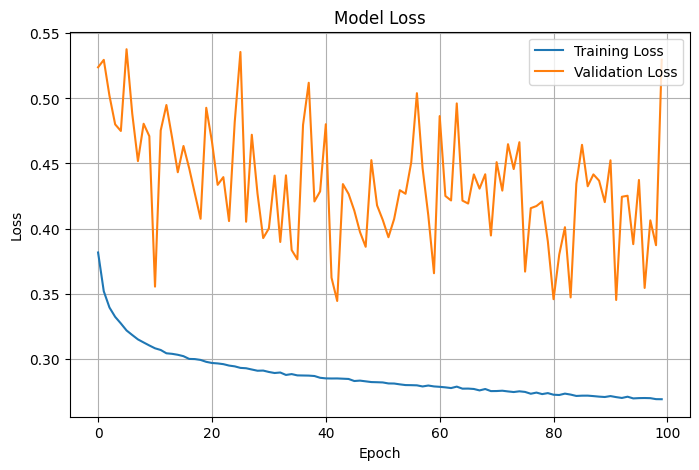

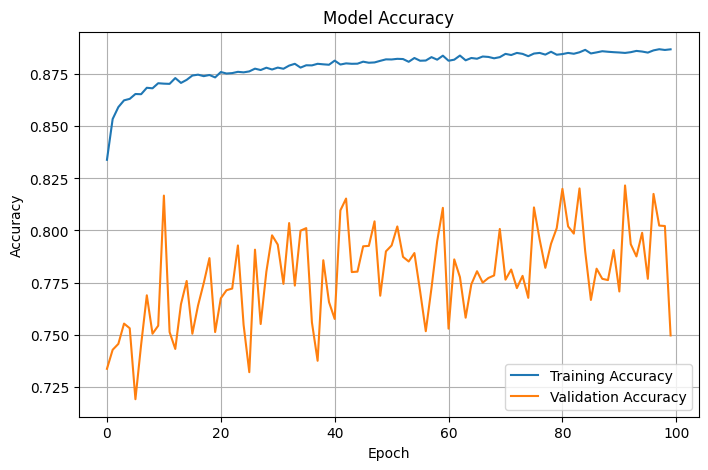

In [28]:
plot_loss(history)
plot_accuracy(history)